# Setup

In [ ]:
# IMPORTS & ENVIRONMENT SETUP

import os
import shutil
import random
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
import torchvision.transforms as transforms
import kagglehub

In [ ]:
# DOWNLOAD DATASET & DEFINE PATHS

path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")
print("Dataset downloaded to:", path)

audio_dataset_path = os.path.join(path, 'Data', 'genres_original')
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Dataset downloaded to: /kaggle/input/gtzan-dataset-music-genre-classification


# Baseline Model

In [ ]:
# FEATURE EXTRACTION & UNDERSAMPLING

def extract_features(file_path):
    """Loads audio and extracts spectral, temporal, and energy features into a 1D array."""
    try:
        y, sr = librosa.load(file_path, duration=30)

        # Spectral Features
        mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20).T, axis=0)
        chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr).T, axis=0)
        spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr).T, axis=0)
        spec_bw = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr).T, axis=0)
        spec_rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr).T, axis=0)

        # Temporal & Energy Features
        zcr = np.mean(librosa.feature.zero_crossing_rate(y).T, axis=0)
        rms = np.mean(librosa.feature.rms(y=y).T, axis=0)

        return np.hstack([mfcc, chroma, spec_cent, spec_bw, spec_rolloff, zcr, rms])
    except Exception:
        return None

print("Extracting features from raw audio...")
genre_features_dict = {g: [] for g in genres}

for genre in genres:
    genre_path = os.path.join(audio_dataset_path, genre)
    for filename in os.listdir(genre_path):
        if filename.endswith('.wav'):
            file_path = os.path.join(genre_path, filename)
            features = extract_features(file_path)
            if features is not None:
                genre_features_dict[genre].append(features)

# Undersample all classes to match the minority class (jazz with 99 samples)
min_samples = min(len(feats) for feats in genre_features_dict.values())
X, y_labels = [], []

# Lock the random selection so it is always exactly the same
random.seed(42)

for genre in genres:
    selected_feats = random.sample(genre_features_dict[genre], min_samples)
    X.extend(selected_feats)
    y_labels.extend([genre] * min_samples)

X = np.array(X)
y_labels = np.array(y_labels)

print(f"Extraction complete. Total balanced samples: {len(X)}")

Extracting features from raw audio...


/tmp/ipykernel_1563/2726731970.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, duration=30)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Extraction complete. Total balanced samples: 990


In [ ]:
# TRAIN/TEST SPLIT & SCALING

# Stratified split to ensure equal representation in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.20, stratify=y_labels, random_state=42
)

# Scale features based on the training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 792
Test set size: 198


In [ ]:
# SVM TRAINING

print("Training the Support Vector Machine (RBF Kernel)...")

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_scaled, y_train)

print("Training complete!")

Training the Support Vector Machine (RBF Kernel)...
Training complete!


In [ ]:
# NUMERICAL EVALUATION

y_pred = svm_model.predict(X_test_scaled)

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred))

Overall Accuracy: 70.20%

Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

       blues       0.73      0.80      0.76        20
   classical       0.84      0.84      0.84        19
     country       0.55      0.60      0.57        20
       disco       0.65      0.65      0.65        20
      hiphop       0.93      0.70      0.80        20
        jazz       0.78      0.70      0.74        20
       metal       0.89      0.80      0.84        20
         pop       0.65      0.85      0.74        20
      reggae       0.65      0.68      0.67        19
        rock       0.44      0.40      0.42        20

    accuracy                           0.70       198
   macro avg       0.71      0.70      0.70       198
weighted avg       0.71      0.70      0.70       198



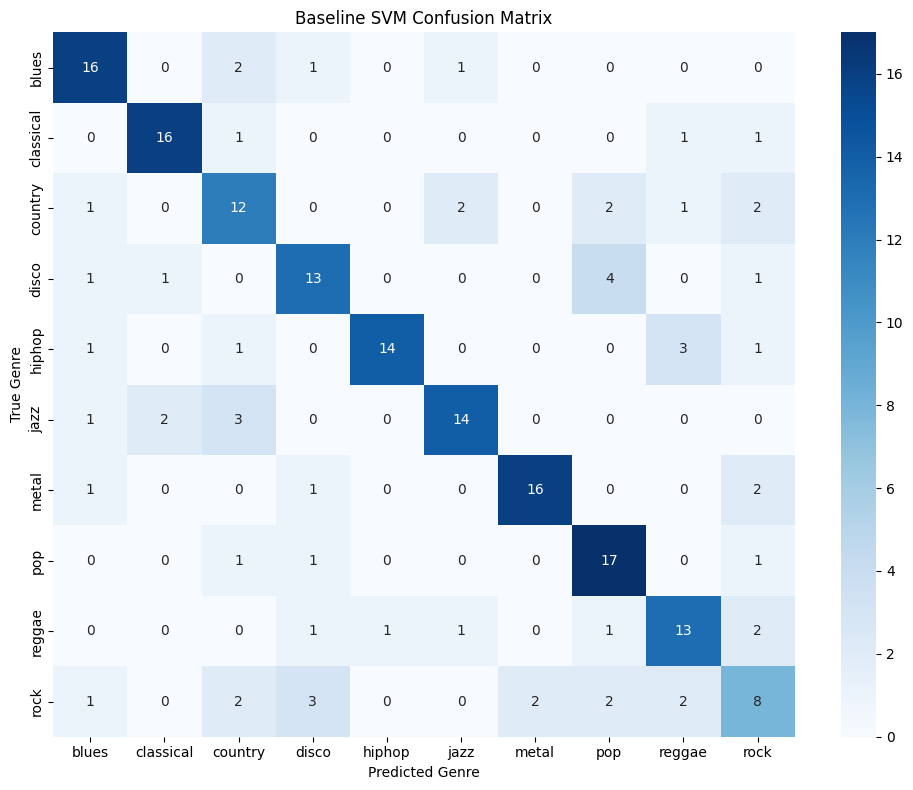

In [ ]:
# VISUAL EVALUATION

cm = confusion_matrix(y_test, y_pred, labels=genres)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=genres, yticklabels=genres)
plt.title('Baseline SVM Confusion Matrix')
plt.ylabel('True Genre')
plt.xlabel('Predicted Genre')
plt.tight_layout()
plt.show()